#                     Titanic Survival Analysis

## 1.The objective of this project is to build a machine learning model that predicts whether a passenger survived the Titanic disaster based on features such as age, gender, passenger class, fare, and family size.
    
    This is a binary classification problem
    Target variable: Survived (0 = No, 1 = Yes)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data undersatanding.

In [17]:
df = pd.read_csv(r"C:\Users\HP\Desktop\data_csv\Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Explaing the data
    PassengerId – Unique ID
    Pclass – Ticket class (1, 2, 3)
    Sex – Gender
    Age – Age of passenger
    SibSp – Siblings/Spouses aboard
    Parch – Parents/Children aboard
    Fare – Ticket fare
    Embarked – Port of embarkation
    Survived – Target variable

    Age, Cabin and Embarked have missing values

## 2.DATA CLEANING

In [4]:
df.fillna({
    'Age' : df['Age'].mean(),
    'Embarked' : df['Embarked'].mode()[0]
},inplace = True)

    Age is filled by mean age of passangers 
    Embarked is flled with mode

In [25]:
df.drop(["Cabin"],axis = 1,errors = 'ignore' , inplace = True)

    Cabin is dropped because to many missing values

In [26]:
df.drop(["Name",'PassengerId','Ticket'] ,axis = 1 , errors = 'ignore',inplace = True)

    REMOVED IRRELAVENT COLUMNS
    PassengerID,Name,Ticket which are not nessasary for prediction
        

## 3.DATA VISUALISATION

    Survival by gender 

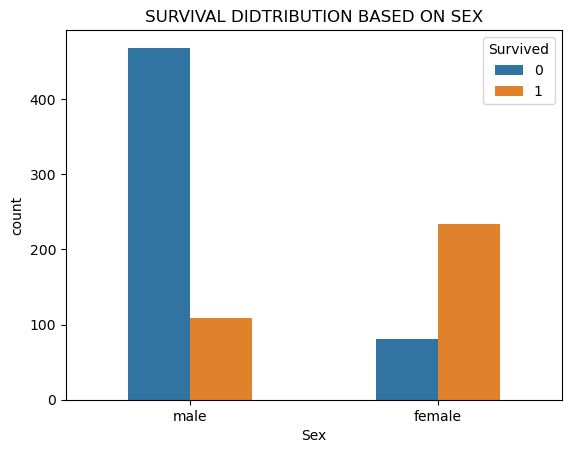

In [13]:
sns.countplot(x='Sex',hue="Survived",data = df,width= 0.5)
plt.title("SURVIVAL DIDTRIBUTION BASED ON SEX")
plt.show()

    The visualization shows that female passengers had a significantly higher survival rate compared to male passengers.
    This suggests that during evacuation, priority may have been given to women, which aligns with the "women and children first" protocol.
    Therefore, gender appears to be a strong predictor of survival.

    Survival by Class

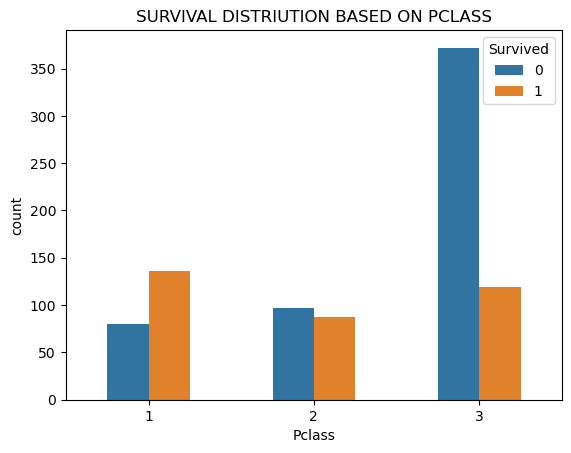

In [12]:
sns.countplot(x='Pclass',hue='Survived',data = df , width = 0.5)
plt.title("SURVIVAL DISTRIUTION BASED ON PCLASS")
plt.show()

    Passengers in 1st class had the highest survival rate, while 2nd class passengers had the lowest.
    This may indicate that higher-class passengers had better access to lifeboats and evacuation assistance.
    Passenger class appears to have a strong relationship with survival probability.

    Age distribution

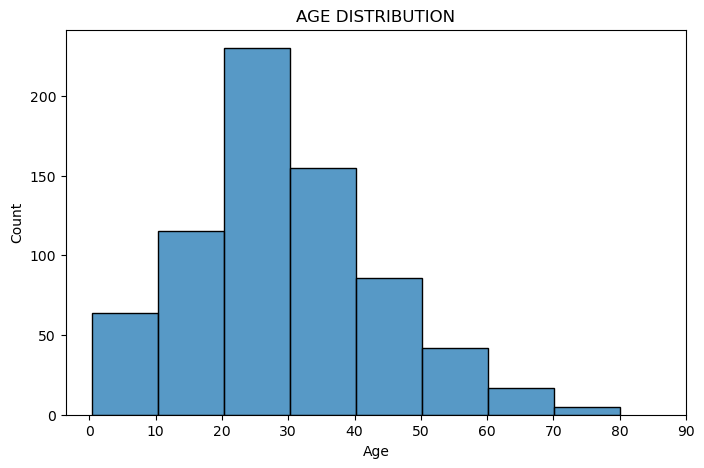

In [38]:
plt.figure(figsize = (8,5))
sns.histplot(df['Age'] , bins = 10 ,binwidth = 10)
plt.title("AGE DISTRIBUTION")
plt.xticks(np.arange(0,100,10))
plt.xlabel('Age')
plt.ylabel('Count')


plt.show()

    Age Distribution by survival

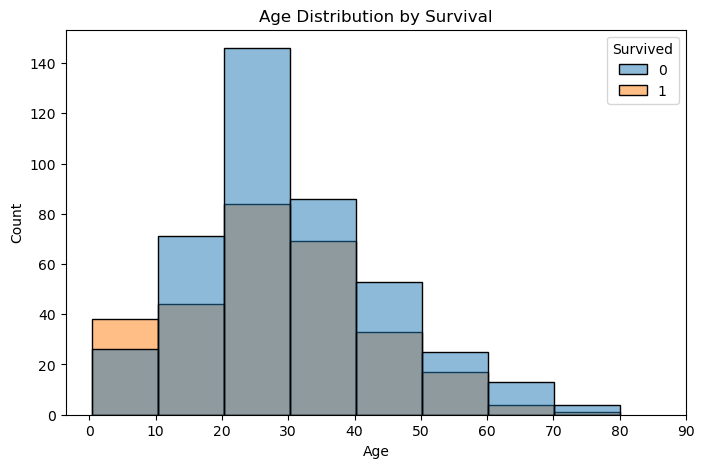

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Age", hue="Survived",
             bins=10, binwidth = 10)

plt.title("Age Distribution by Survival")
plt.xticks(np.arange(0,100,10))
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

    The distribution shows that most passengers were between 20–40 years old. A noticeable concentration of younger passengers appears among survivors, suggesting that children may have been prioritized during evacuation.